# 3D Car Detection Training and Inference using KITTI dataset


## What this notebook does
- uses the first 2000 frames for training
- uses the next 200 frames for validation
- caches data after pillarization
- trains a compact PointPillars-like model
- saves the best checkpoint
- runs inference on the best checkpoint
- KITTI mAP evaluation


This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


## 1. Imports and runtime setup

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [1]:
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. User configuration

Edit only this cell if your local paths or training settings are different.

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [2]:

VEL_DIR = Path(r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\data\data_object_velodyne\training\velodyne")
LAB_DIR = Path(r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\data\data_object_label_2\training\label_2")
CAL_DIR = Path(r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\data\data_object_calib\training\calib")

CACHE_ROOT = Path(r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\3D_obj\cache_pfn_input_car_only")
CHECKPOINT_DIR = Path(r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\3D_obj\checkpoints")

NUM_TRAIN_FRAMES = 2000
NUM_VAL_FRAMES = 200


X_MIN, X_MAX = 0.0, 70.4
Y_MIN, Y_MAX = -40.0, 40.0
PILLAR_SIZE = 0.16
MAX_POINTS_PER_PILLAR = 32
MAX_PILLARS = 12000

# Derived grid size
GRID_H = int(round((X_MAX - X_MIN) / PILLAR_SIZE))   # 440
GRID_W = int(round((Y_MAX - Y_MIN) / PILLAR_SIZE))   # 500


BATCH_SIZE = 4
NUM_WORKERS = 0       
EPOCHS = 40
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
USE_AMP = True
GRAD_CLIP_NORM = 10.0


HEAD_STRIDE = 2
HEAD_H = GRID_H // HEAD_STRIDE
HEAD_W = GRID_W // HEAD_STRIDE
ANCHOR_YAWS = [0.0, math.pi / 2.0]


REBUILD_CACHE = False


CACHE_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("GRID_H, GRID_W =", GRID_H, GRID_W)
print("HEAD_H, HEAD_W =", HEAD_H, HEAD_W)


GRID_H, GRID_W = 440 500
HEAD_H, HEAD_W = 220 250


## 3. Basic path checks

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [3]:
for p in [VEL_DIR, LAB_DIR, CAL_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Path does not exist: {p}")

all_bin_files = sorted(VEL_DIR.glob("*.bin"))
print("Total velodyne frames found:", len(all_bin_files))

required_frames = NUM_TRAIN_FRAMES + NUM_VAL_FRAMES
if len(all_bin_files) < required_frames:
    raise ValueError(
        f"Need at least {required_frames} frames, but found only {len(all_bin_files)}."
    )


Total velodyne frames found: 7481


## 4. KITTI parsing helpers

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [4]:
def load_kitti_velodyne(bin_path: Path) -> np.ndarray:
    points = np.fromfile(str(bin_path), dtype=np.float32)
    return points.reshape(-1, 4)

def read_calib(calib_file: Path):
    data = {}
    with open(calib_file, "r") as f:
        for line in f:
            if ":" not in line:
                continue
            key, value = line.split(":", 1)
            data[key] = np.array([float(x) for x in value.strip().split()], dtype=np.float64)

    R0 = data["R0_rect"].reshape(3, 3)
    Tr = data["Tr_velo_to_cam"].reshape(3, 4)

    R0_4 = np.eye(4, dtype=np.float64)
    R0_4[:3, :3] = R0

    Tr_4 = np.eye(4, dtype=np.float64)
    Tr_4[:3, :4] = Tr
    return R0_4, Tr_4

def inverse_rigid_transform(T: np.ndarray) -> np.ndarray:
    R = T[:3, :3]
    t = T[:3, 3]
    T_inv = np.eye(4, dtype=T.dtype)
    T_inv[:3, :3] = R.T
    T_inv[:3, 3] = -R.T @ t
    return T_inv

def read_kitti_labels_car(label_path: Path):
    cars = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 15:
                continue
            if parts[0] != "Car":
                continue

            h, w, l = map(float, parts[8:11])
            x, y, z = map(float, parts[11:14])
            ry = float(parts[14])

            cars.append({
                "h": h,
                "w": w,
                "l": l,
                "x": x,
                "y": y,
                "z": z,
                "ry": ry,
            })
    return cars

def roty(ry: float) -> np.ndarray:
    c = np.cos(ry)
    s = np.sin(ry)
    return np.array([
        [ c, 0,  s],
        [ 0, 1,  0],
        [-s, 0,  c],
    ], dtype=np.float64)

def box3d_cam_corners(h, w, l, x, y, z, ry) -> np.ndarray:
    x_corners = np.array([ l/2,  l/2, -l/2, -l/2,  l/2,  l/2, -l/2, -l/2], dtype=np.float64)
    y_corners = np.array([ 0.0,  0.0,  0.0,  0.0, -h,   -h,   -h,   -h  ], dtype=np.float64)
    z_corners = np.array([ w/2, -w/2, -w/2,  w/2,  w/2, -w/2, -w/2,  w/2], dtype=np.float64)

    corners = np.vstack([x_corners, y_corners, z_corners])
    corners = roty(ry) @ corners
    corners[0] += x
    corners[1] += y
    corners[2] += z
    return corners.T

def transform_points(T: np.ndarray, pts: np.ndarray) -> np.ndarray:
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1), dtype=pts.dtype)])
    out = (T @ pts_h.T).T
    return out[:, :3]

def camera_cars_to_lidar_boxes(cars_cam, T_rect_to_velo, x_min, x_max, y_min, y_max):
    T = np.asarray(T_rect_to_velo, dtype=np.float64)
    R = T[:3, :3]

    boxes = []

    for car in cars_cam:
        h = float(car["h"])
        w = float(car["w"])
        l = float(car["l"])
        x = float(car["x"])
        y = float(car["y"])
        z = float(car["z"])
        ry = float(car["ry"])

        p_cam = np.array([x, y, z, 1.0], dtype=np.float64)
        p_velo = (T @ p_cam)[:3]

        center_velo = p_velo.copy()
        center_velo[2] += 0.5 * h

        c = math.cos(ry)
        s = math.sin(ry)
        heading_cam = np.array([c, 0.0, -s], dtype=np.float64)  

        heading_velo = R @ heading_cam
        yaw = float(math.atan2(heading_velo[1], heading_velo[0]))

        cx, cy, cz = center_velo.astype(np.float32)

        if not (x_min <= cx < x_max and y_min <= cy < y_max):
            continue

        boxes.append([cx, cy, cz, np.float32(l), np.float32(w), np.float32(h), np.float32(yaw)])

    if len(boxes) == 0:
        return np.zeros((0, 7), dtype=np.float32)

    return np.asarray(boxes, dtype=np.float32)

## 5. Sequential split: first 1000 for training, next 100 for validation

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [5]:
def get_ordered_frame_ids(vel_dir: Path):
    return sorted(p.stem for p in vel_dir.glob("*.bin"))

all_frame_ids = get_ordered_frame_ids(VEL_DIR)
train_ids = all_frame_ids[:NUM_TRAIN_FRAMES]
val_ids = all_frame_ids[NUM_TRAIN_FRAMES:NUM_TRAIN_FRAMES + NUM_VAL_FRAMES]

print("Train frames:", len(train_ids), train_ids[:3], "...", train_ids[-3:])
print("Val frames:", len(val_ids), val_ids[:3], "...", val_ids[-3:])

split_info = {
    "num_train_frames": len(train_ids),
    "num_val_frames": len(val_ids),
    "train_first_id": train_ids[0],
    "train_last_id": train_ids[-1],
    "val_first_id": val_ids[0],
    "val_last_id": val_ids[-1],
}
split_info


Train frames: 2000 ['000000', '000001', '000002'] ... ['001997', '001998', '001999']
Val frames: 200 ['002000', '002001', '002002'] ... ['002197', '002198', '002199']


{'num_train_frames': 2000,
 'num_val_frames': 200,
 'train_first_id': '000000',
 'train_last_id': '001999',
 'val_first_id': '002000',
 'val_last_id': '002199'}

## 6. Pillarization and cache creation

Each cached `.npz` file stores:
- `pillar_points` with shape `(P, 32, 4)`
- `pillar_indices` with shape `(P, 2)`
- `num_points_per_pillar` with shape `(P,)`
- `gt_boxes` with shape `(M, 7)` in lidar coordinates
- `grid_size`
- `frame_id`

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [6]:
def pillarize(points_xyzi: np.ndarray):
    if points_xyzi.ndim != 2 or points_xyzi.shape[1] != 4:
        raise ValueError(f"Expected points shape (N,4), got {points_xyzi.shape}")

    points_xyzi = np.asarray(points_xyzi, dtype=np.float32)

    x = points_xyzi[:, 0]
    y = points_xyzi[:, 1]

    roi_mask = (
        (x >= X_MIN) & (x < X_MAX) &
        (y >= Y_MIN) & (y < Y_MAX)
    )
    pts = points_xyzi[roi_mask]

    if pts.shape[0] == 0:
        return (
            np.zeros((0, MAX_POINTS_PER_PILLAR, 4), dtype=np.float32),
            np.zeros((0, 2), dtype=np.int32),
            np.zeros((0,), dtype=np.int32),
            np.array([GRID_H, GRID_W], dtype=np.int32),
        )

    x_idx = np.floor((pts[:, 0] - X_MIN) / PILLAR_SIZE).astype(np.int32)
    y_idx = np.floor((pts[:, 1] - Y_MIN) / PILLAR_SIZE).astype(np.int32)

    x_idx = np.clip(x_idx, 0, GRID_H - 1)
    y_idx = np.clip(y_idx, 0, GRID_W - 1)

    keys = x_idx.astype(np.int64) * GRID_W + y_idx.astype(np.int64)
    order = np.argsort(keys, kind="mergesort")

    pts = pts[order]
    x_idx = x_idx[order]
    y_idx = y_idx[order]
    keys = keys[order]

    _, start_idx, counts = np.unique(keys, return_index=True, return_counts=True)

    num_pillars = min(int(len(start_idx)), int(MAX_PILLARS))
    start_idx = start_idx[:num_pillars]
    counts = counts[:num_pillars]

    pillar_points = np.zeros((num_pillars, MAX_POINTS_PER_PILLAR, 4), dtype=np.float32)
    pillar_indices = np.zeros((num_pillars, 2), dtype=np.int32)
    num_points_per_pillar = np.zeros((num_pillars,), dtype=np.int32)

    for i in range(num_pillars):
        s = int(start_idx[i])
        c = int(counts[i])
        take = min(c, MAX_POINTS_PER_PILLAR)

        pillar_points[i, :take, :] = pts[s:s + take]
        pillar_indices[i, 0] = x_idx[s]
        pillar_indices[i, 1] = y_idx[s]
        num_points_per_pillar[i] = take

    return (
        pillar_points,
        pillar_indices,
        num_points_per_pillar,
        np.array([GRID_H, GRID_W], dtype=np.int32),
    )


def save_cache_file(
    out_path: Path,
    pillar_points: np.ndarray,
    pillar_indices: np.ndarray,
    num_points_per_pillar: np.ndarray,
    gt_boxes: np.ndarray,
    grid_size: np.ndarray,
    frame_id: str,
):
    out_path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_path,
        pillar_points=np.asarray(pillar_points, dtype=np.float32),
        pillar_indices=np.asarray(pillar_indices, dtype=np.int32),
        num_points_per_pillar=np.asarray(num_points_per_pillar, dtype=np.int32),
        gt_boxes=np.asarray(gt_boxes, dtype=np.float32),
        grid_size=np.asarray(grid_size, dtype=np.int32),
        frame_id=np.array(str(frame_id)),
    )


def build_cache_for_split(frame_ids: Iterable[str], split_name: str):
    split_dir = CACHE_ROOT / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    for frame_id in tqdm(frame_ids, desc=f"Building cache: {split_name}"):
        bin_path = VEL_DIR / f"{frame_id}.bin"
        lab_path = LAB_DIR / f"{frame_id}.txt"
        cal_path = CAL_DIR / f"{frame_id}.txt"

        if not bin_path.exists():
            raise FileNotFoundError(f"Missing velodyne file: {bin_path}")
        if not lab_path.exists():
            raise FileNotFoundError(f"Missing label file: {lab_path}")
        if not cal_path.exists():
            raise FileNotFoundError(f"Missing calib file: {cal_path}")

        points = load_kitti_velodyne(bin_path)
        cars_cam = read_kitti_labels_car(lab_path)

        R0_4, Tr_4 = read_calib(cal_path)
        T_velo_to_rect = R0_4 @ Tr_4
        T_rect_to_velo = inverse_rigid_transform(T_velo_to_rect)

        pillar_points, pillar_indices, num_points_per_pillar, grid_size = pillarize(points)

        gt_boxes = camera_cars_to_lidar_boxes(
            cars_cam=cars_cam,
            T_rect_to_velo=T_rect_to_velo,
            x_min=X_MIN,
            x_max=X_MAX,
            y_min=Y_MIN,
            y_max=Y_MAX,
        )

        out_path = split_dir / f"{frame_id}.npz"
        save_cache_file(
            out_path=out_path,
            pillar_points=pillar_points,
            pillar_indices=pillar_indices,
            num_points_per_pillar=num_points_per_pillar,
            gt_boxes=gt_boxes,
            grid_size=grid_size,
            frame_id=frame_id,
        )


def get_cache_metadata():
    return {
        "train_ids": list(train_ids),
        "val_ids": list(val_ids),
        "grid_h": int(GRID_H),
        "grid_w": int(GRID_W),
        "pillar_size": float(PILLAR_SIZE),
        "x_min": float(X_MIN),
        "x_max": float(X_MAX),
        "y_min": float(Y_MIN),
        "y_max": float(Y_MAX),
        "max_points_per_pillar": int(MAX_POINTS_PER_PILLAR),
        "max_pillars": int(MAX_PILLARS),
    }


def split_cache_is_ready():
    train_dir = CACHE_ROOT / "train"
    val_dir = CACHE_ROOT / "val"
    meta_path = CACHE_ROOT / "split_metadata.json"

    if not train_dir.exists() or not val_dir.exists() or not meta_path.exists():
        return False

    train_files = sorted(train_dir.glob("*.npz"))
    val_files = sorted(val_dir.glob("*.npz"))

    if len(train_files) != len(train_ids):
        return False
    if len(val_files) != len(val_ids):
        return False

    try:
        with open(meta_path, "r") as f:
            old_meta = json.load(f)
    except Exception:
        return False

    return old_meta == get_cache_metadata()


def remove_old_cache():
    for name in ["train", "val"]:
        split_dir = CACHE_ROOT / name
        if split_dir.exists():
            shutil.rmtree(split_dir)

    meta_path = CACHE_ROOT / "split_metadata.json"
    if meta_path.exists():
        meta_path.unlink()


CACHE_ROOT.mkdir(parents=True, exist_ok=True)

if REBUILD_CACHE or (not split_cache_is_ready()):
    print("Building cache files...")

    remove_old_cache()
    build_cache_for_split(train_ids, "train")
    build_cache_for_split(val_ids, "val")

    metadata = get_cache_metadata()
    with open(CACHE_ROOT / "split_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("Cache build complete:", CACHE_ROOT)
else:
    print("Cache already exists. Using cached files from:", CACHE_ROOT)

Cache already exists. Using cached files from: C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\3D_obj\cache_pfn_input_car_only


## 7. Quick cache inspection

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [7]:
train_cache_files = sorted((CACHE_ROOT / "train").glob("*.npz"))
val_cache_files = sorted((CACHE_ROOT / "val").glob("*.npz"))

print("Cached train files:", len(train_cache_files))
print("Cached val files:", len(val_cache_files))

sample_cache = train_cache_files[0]
sample = np.load(sample_cache)

print("Sample file:", sample_cache.name)
print("pillar_points:", sample["pillar_points"].shape, sample["pillar_points"].dtype)
print("pillar_indices:", sample["pillar_indices"].shape, sample["pillar_indices"].dtype)
print("num_points_per_pillar:", sample["num_points_per_pillar"].shape, sample["num_points_per_pillar"].dtype)
print("gt_boxes:", sample["gt_boxes"].shape, sample["gt_boxes"].dtype)
print("grid_size:", sample["grid_size"])
print("frame_id:", sample["frame_id"].item())


Cached train files: 2000
Cached val files: 200
Sample file: 000000.npz
pillar_points: (8347, 32, 4) float32
pillar_indices: (8347, 2) int32
num_points_per_pillar: (8347,) int32
gt_boxes: (0, 7) float32
grid_size: [440 500]
frame_id: 000000


## 8. Dataset and dataloaders

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [8]:
class PillarCacheDataset(Dataset):
    def __init__(self, cache_dir: Path, expected_grid_size=None):
        self.cache_dir = Path(cache_dir)
        self.files = sorted(self.cache_dir.glob("*.npz"))

        if len(self.files) == 0:
            raise FileNotFoundError(f"No cache files found in {self.cache_dir}")

        self.expected_grid_size = None
        if expected_grid_size is not None:
            self.expected_grid_size = np.asarray(expected_grid_size, dtype=np.int32)

        # quick validation on first file
        sample = self._read_npz(self.files[0])
        required_keys = {
            "pillar_points",
            "pillar_indices",
            "num_points_per_pillar",
            "gt_boxes",
            "grid_size",
            "frame_id",
        }
        missing = required_keys.difference(sample.keys())
        if missing:
            raise KeyError(f"Cache file {self.files[0]} is missing keys: {sorted(missing)}")

        if self.expected_grid_size is not None:
            if not np.array_equal(sample["grid_size"].astype(np.int32), self.expected_grid_size):
                raise ValueError(
                    f"Grid size mismatch in {self.files[0]}. "
                    f"Found {sample['grid_size']}, expected {self.expected_grid_size}."
                )

    def _read_npz(self, path: Path):
        try:
            with np.load(path) as data:
                out = {k: data[k] for k in data.files}
            return out
        except Exception as e:
            raise RuntimeError(f"Failed to read cache file: {path}") from e

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        data = self._read_npz(path)

        try:
            pillar_points = data["pillar_points"].astype(np.float32, copy=False)
            pillar_indices = data["pillar_indices"].astype(np.int32, copy=False)
            num_points_per_pillar = data["num_points_per_pillar"].astype(np.int32, copy=False)
            gt_boxes = data["gt_boxes"].astype(np.float32, copy=False)
            grid_size = data["grid_size"].astype(np.int32, copy=False)
            frame_id = str(data["frame_id"].item())
        except Exception as e:
            raise RuntimeError(f"Invalid contents in cache file: {path}") from e

        if pillar_points.ndim != 3 or pillar_points.shape[-1] != 4:
            raise ValueError(f"{path} has invalid pillar_points shape: {pillar_points.shape}")
        if pillar_indices.ndim != 2 or pillar_indices.shape[-1] != 2:
            raise ValueError(f"{path} has invalid pillar_indices shape: {pillar_indices.shape}")
        if num_points_per_pillar.ndim != 1:
            raise ValueError(f"{path} has invalid num_points_per_pillar shape: {num_points_per_pillar.shape}")
        if gt_boxes.ndim != 2 or gt_boxes.shape[-1] != 7:
            raise ValueError(f"{path} has invalid gt_boxes shape: {gt_boxes.shape}")
        if grid_size.shape != (2,):
            raise ValueError(f"{path} has invalid grid_size shape: {grid_size.shape}")

        num_pillars = pillar_points.shape[0]
        if pillar_indices.shape[0] != num_pillars or num_points_per_pillar.shape[0] != num_pillars:
            raise ValueError(
                f"{path} has inconsistent pillar dimensions: "
                f"pillar_points={pillar_points.shape}, "
                f"pillar_indices={pillar_indices.shape}, "
                f"num_points_per_pillar={num_points_per_pillar.shape}"
            )

        if self.expected_grid_size is not None and not np.array_equal(grid_size, self.expected_grid_size):
            raise ValueError(
                f"{path} grid size mismatch. Found {grid_size}, expected {self.expected_grid_size}."
            )

        return {
            "pillar_points": pillar_points,
            "pillar_indices": pillar_indices,
            "num_points_per_pillar": num_points_per_pillar,
            "gt_boxes": gt_boxes,
            "grid_size": grid_size,
            "frame_id": frame_id,
        }


def pillar_collate_fn(batch):
    return {
        "pillar_points": [torch.from_numpy(item["pillar_points"]).float() for item in batch],
        "pillar_indices": [torch.from_numpy(item["pillar_indices"]).long() for item in batch],
        "num_points_per_pillar": [torch.from_numpy(item["num_points_per_pillar"]).long() for item in batch],
        "gt_boxes": [torch.from_numpy(item["gt_boxes"]).float() for item in batch],
        "grid_size": [item["grid_size"] for item in batch],
        "frame_id": [item["frame_id"] for item in batch],
    }


expected_grid_size = np.array([GRID_H, GRID_W], dtype=np.int32)

train_ds = PillarCacheDataset(CACHE_ROOT / "train", expected_grid_size=expected_grid_size)
val_ds = PillarCacheDataset(CACHE_ROOT / "val", expected_grid_size=expected_grid_size)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
    collate_fn=pillar_collate_fn,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
    collate_fn=pillar_collate_fn,
)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train samples: 2000
Val samples: 200
Train batches: 500
Val batches: 50


## 9. Estimate anchor statistics from the training cache

Instead of hard-coding the anchor size, this notebook estimates a single average **Car** anchor from the training split.

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [9]:
def estimate_anchor_stats(cache_dir: Path):

    cache_dir = Path(cache_dir)
    files = sorted(cache_dir.glob("*.npz"))

    if len(files) == 0:
        raise FileNotFoundError(f"No cache files found in {cache_dir}")

    all_boxes = []

    for file in files:
        try:
            with np.load(file) as d:
                if "gt_boxes" not in d:
                    raise KeyError(f"'gt_boxes' missing in {file}")

                gt_boxes = np.asarray(d["gt_boxes"], dtype=np.float32)

                if gt_boxes.ndim != 2 or gt_boxes.shape[1] != 7:
                    raise ValueError(f"Invalid gt_boxes shape in {file}: {gt_boxes.shape}")

                if gt_boxes.shape[0] > 0:
                    all_boxes.append(gt_boxes)
        except Exception as e:
            raise RuntimeError(f"Failed while reading GT boxes from {file}") from e

    if len(all_boxes) == 0:
        print("No GT boxes found in training cache. Falling back to defaults.")
        return {
            "anchor_l": 3.9,
            "anchor_w": 1.6,
            "anchor_h": 1.56,
            "anchor_z": -1.0,
        }

    all_boxes = np.concatenate(all_boxes, axis=0)

    anchor_l = float(np.median(all_boxes[:, 3]))
    anchor_w = float(np.median(all_boxes[:, 4]))
    anchor_h = float(np.median(all_boxes[:, 5]))
    anchor_z = float(np.median(all_boxes[:, 2]))

    return {
        "anchor_l": anchor_l,
        "anchor_w": anchor_w,
        "anchor_h": anchor_h,
        "anchor_z": anchor_z,
    }


anchor_stats = estimate_anchor_stats(CACHE_ROOT / "train")
print(anchor_stats)

{'anchor_l': 3.880000114440918, 'anchor_w': 1.6299999952316284, 'anchor_h': 1.5, 'anchor_z': -0.8050491809844971}


## 10. PointPillars-style model (training-only)

This is a compact, notebook-friendly model:
- PFN
- scatter to BEV
- lightweight 2D backbone
- neck
- anchor head

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [10]:
class PFNLayer(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, use_layernorm: bool = True):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels, bias=False)
        self.use_layernorm = use_layernorm
        self.norm = (
            nn.LayerNorm(out_channels, eps=1e-5)
            if use_layernorm
            else nn.BatchNorm1d(out_channels, eps=1e-3, momentum=0.01)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        x = self.linear(x)  # (P, T, C_out)

        if mask.any():
            x_valid = x[mask]  # (N_valid, C_out)

            # Normalize in fp32, then cast back to x dtype for safe masked assignment under AMP
            x_valid_norm = self.norm(x_valid.float()).to(dtype=x.dtype)

            x = x.clone()
            x[mask] = x_valid_norm
        else:
            x = torch.zeros_like(x)

        x = self.relu(x)

        # Max pool over points; invalid points must not win
        neg_inf = torch.finfo(x.dtype).min
        x = x.masked_fill(~mask.unsqueeze(-1), neg_inf)

        return x.max(dim=1).values  # (P, C_out)


class PillarFeatureNet(nn.Module):
    def __init__(self, in_channels=9, out_channels=64):
        super().__init__()
        self.pfn = PFNLayer(in_channels, out_channels, use_layernorm=True)
        self.out_channels = out_channels

    def forward(self, pillar_points, pillar_indices, num_points_per_pillar):
        B = len(pillar_points)
        device = pillar_points[0].device

        bev = torch.zeros(
            (B, self.out_channels, GRID_H, GRID_W),
            dtype=torch.float32,
            device=device,
        )

        for b in range(B):
            pts = pillar_points[b].float()
            inds = pillar_indices[b].long()
            cnts = num_points_per_pillar[b].long()

            if pts.numel() == 0:
                continue

            P, T, _ = pts.shape

            t_index = torch.arange(T, device=device).view(1, T)
            mask = t_index < cnts.view(P, 1)  # (P,T)

            xyz = pts[..., :3]
            intensity = pts[..., 3]

            counts = cnts.clamp(min=1).float().view(P, 1, 1)
            xyz_mean = (xyz * mask.unsqueeze(-1).float()).sum(dim=1, keepdim=True) / counts

            x_rel = xyz[..., 0] - xyz_mean[..., 0]
            y_rel = xyz[..., 1] - xyz_mean[..., 1]
            z_rel = xyz[..., 2] - xyz_mean[..., 2]

            x_center = (inds[:, 0].float() + 0.5) * PILLAR_SIZE + X_MIN
            y_center = (inds[:, 1].float() + 0.5) * PILLAR_SIZE + Y_MIN

            x_center_rel = xyz[..., 0] - x_center[:, None]
            y_center_rel = xyz[..., 1] - y_center[:, None]

            pfn_input = torch.stack(
                [
                    xyz[..., 0], xyz[..., 1], xyz[..., 2],
                    intensity,
                    x_rel, y_rel, z_rel,
                    x_center_rel, y_center_rel,
                ],
                dim=-1
            )

            pfn_input = pfn_input * mask.unsqueeze(-1).float()
            pillar_features = self.pfn(pfn_input, mask)  # (P,C)

            x_idx = inds[:, 0].clamp(0, GRID_H - 1)
            y_idx = inds[:, 1].clamp(0, GRID_W - 1)

            hw = GRID_H * GRID_W
            lin_idx = (x_idx * GRID_W + y_idx).long()              # (P,)
            feat_cp = pillar_features.t().to(dtype=bev.dtype)      # (C,P)

            neg_inf = torch.finfo(bev.dtype).min
            flat = torch.full((self.out_channels, hw), neg_inf, device=device, dtype=bev.dtype)

            idx2d = lin_idx.view(1, -1).expand(self.out_channels, -1)  # (C,P)
            flat.scatter_reduce_(dim=1, index=idx2d, src=feat_cp, reduce="amax", include_self=True)

            # turn untouched cells back to 0
            flat = torch.where(flat == neg_inf, torch.zeros_like(flat), flat)

            bev[b] = flat.view(self.out_channels, GRID_H, GRID_W)

        return bev


class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=k, stride=s, padding=p, bias=False),
            nn.BatchNorm2d(c_out, eps=1e-3, momentum=0.01),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Backbone2D(nn.Module):
    def __init__(self, in_channels=64):
        super().__init__()
        self.block1 = nn.Sequential(
            ConvBlock(in_channels, 64, 3, 2, 1),
            ConvBlock(64, 64, 3, 1, 1),
            ConvBlock(64, 64, 3, 1, 1),
        )
        self.block2 = nn.Sequential(
            ConvBlock(64, 128, 3, 2, 1),
            ConvBlock(128, 128, 3, 1, 1),
            ConvBlock(128, 128, 3, 1, 1),
        )
        self.block3 = nn.Sequential(
            ConvBlock(128, 256, 3, 2, 1),
            ConvBlock(256, 256, 3, 1, 1),
            ConvBlock(256, 256, 3, 1, 1),
        )

    def forward(self, x):
        x1 = self.block1(x)   # stride 2
        x2 = self.block2(x1)  # stride 4
        x3 = self.block3(x2)  # stride 8
        return x1, x2, x3


class NeckFPN(nn.Module):
    def __init__(self):
        super().__init__()
        self.reduce1 = ConvBlock(64, 128, 1, 1, 0)
        self.reduce2 = ConvBlock(128, 128, 1, 1, 0)
        self.reduce3 = ConvBlock(256, 128, 1, 1, 0)

    def forward(self, x1, x2, x3):
        x1 = self.reduce1(x1)
        x2 = self.reduce2(x2)
        x3 = self.reduce3(x3)
        x2 = F.interpolate(x2, size=x1.shape[-2:], mode="bilinear", align_corners=False)
        x3 = F.interpolate(x3, size=x1.shape[-2:], mode="bilinear", align_corners=False)
        return torch.cat([x1, x2, x3], dim=1)  # (B,384,H/2,W/2)


class AnchorHead(nn.Module):
    def __init__(self, in_channels=384, num_anchors=2):
        super().__init__()
        self.shared = nn.Sequential(
            ConvBlock(in_channels, 256, 3, 1, 1),
            ConvBlock(256, 256, 3, 1, 1),
        )
        self.cls_head = nn.Conv2d(256, num_anchors, kernel_size=1)
        self.box_head = nn.Conv2d(256, num_anchors * 7, kernel_size=1)
        self.dir_head = nn.Conv2d(256, num_anchors * 2, kernel_size=1)

    def forward(self, x):
        x = self.shared(x)
        return self.cls_head(x), self.box_head(x), self.dir_head(x)


class PointPillarsCarDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.pfn = PillarFeatureNet(in_channels=9, out_channels=64)
        self.backbone = Backbone2D(in_channels=64)
        self.neck = NeckFPN()
        self.head = AnchorHead(in_channels=384, num_anchors=len(ANCHOR_YAWS))

    def forward(self, pillar_points, pillar_indices, num_points_per_pillar):
        bev = self.pfn(pillar_points, pillar_indices, num_points_per_pillar)
        x1, x2, x3 = self.backbone(bev)
        fused = self.neck(x1, x2, x3)  # stride-2 map
        cls_logits, box_reg, dir_logits = self.head(fused)
        return {
            "bev": bev,
            "cls_logits": cls_logits,
            "box_reg": box_reg,
            "dir_logits": dir_logits,
            "head_hw": torch.tensor([cls_logits.shape[-2], cls_logits.shape[-1]], device=cls_logits.device),
        }


model = PointPillarsCarDetector().to(device)
print("Model created.")
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Model created.
Trainable parameters: 3496020


## 11. Anchors, target assignment, and loss

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [11]:
def limit_period(val, offset=0.5, period=math.pi):
    return val - torch.floor(val / period + offset) * period


def generate_anchors(device):
    anchor_l = float(anchor_stats["anchor_l"])
    anchor_w = float(anchor_stats["anchor_w"])
    anchor_h = float(anchor_stats["anchor_h"])
    anchor_z = float(anchor_stats["anchor_z"])

    xs = torch.arange(HEAD_H, device=device, dtype=torch.float32)
    ys = torch.arange(HEAD_W, device=device, dtype=torch.float32)

    x_centers = (xs + 0.5) * (PILLAR_SIZE * HEAD_STRIDE) + X_MIN
    y_centers = (ys + 0.5) * (PILLAR_SIZE * HEAD_STRIDE) + Y_MIN

    xx, yy = torch.meshgrid(x_centers, y_centers, indexing="ij")  # (H, W)

    anchors = []
    for yaw in ANCHOR_YAWS:
        z = torch.full_like(xx, anchor_z)
        l = torch.full_like(xx, anchor_l)
        w = torch.full_like(xx, anchor_w)
        h = torch.full_like(xx, anchor_h)
        yaw_map = torch.full_like(xx, float(yaw))
        anchors.append(torch.stack([xx, yy, z, l, w, h, yaw_map], dim=-1))

    return torch.stack(anchors, dim=0)  # (A,H,W,7)


def encode_boxes(gt_boxes, anchors):
    xa, ya, za, la, wa, ha, ra = anchors.unbind(-1)
    xg, yg, zg, lg, wg, hg, rg = gt_boxes.unbind(-1)

    diagonal = torch.sqrt(la ** 2 + wa ** 2).clamp(min=1e-6)

    tx = (xg - xa) / diagonal
    ty = (yg - ya) / diagonal
    tz = (zg - za) / ha.clamp(min=1e-6)

    tl = torch.log((lg / la).clamp(min=1e-6))
    tw = torch.log((wg / wa).clamp(min=1e-6))
    th = torch.log((hg / ha).clamp(min=1e-6))

    tr = limit_period(rg - ra, offset=0.5, period=2.0 * math.pi)

    return torch.stack([tx, ty, tz, tl, tw, th, tr], dim=-1)


def _rect_corners_xy_ccw(cx, cy, l, w, yaw):
    c = math.cos(float(yaw))
    s = math.sin(float(yaw))
    dx = float(l) / 2.0
    dy = float(w) / 2.0

    # CCW local corners
    local = [( dx,  dy), (-dx,  dy), (-dx, -dy), ( dx, -dy)]

    out = []
    for px, py in local:
        x = cx + px * c - py * s
        y = cy + px * s + py * c
        out.append((x, y))
    return out


def _poly_area(poly):
    if len(poly) < 3:
        return 0.0
    area = 0.0
    for i in range(len(poly)):
        x1, y1 = poly[i]
        x2, y2 = poly[(i + 1) % len(poly)]
        area += x1 * y2 - x2 * y1
    return abs(area) * 0.5


def _inside_left(p, a, b):
    return (b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0]) >= 0.0


def _intersect(p1, p2, a1, a2):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = a1
    x4, y4 = a2
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < 1e-12:
        return p2
    px = ((x1 * y2 - y1 * x2) * (x3 - x4) - (x1 - x2) * (x3 * y4 - y3 * x4)) / den
    py = ((x1 * y2 - y1 * x2) * (y3 - y4) - (y1 - y2) * (x3 * y4 - y3 * x4)) / den
    return (px, py)


def _clip_suth_hodg(subject, clipper):
    out = subject
    for i in range(len(clipper)):
        inp = out
        out = []
        A = clipper[i]
        B = clipper[(i + 1) % len(clipper)]
        if not inp:
            break
        S = inp[-1]
        for E in inp:
            if _inside_left(E, A, B):
                if not _inside_left(S, A, B):
                    out.append(_intersect(S, E, A, B))
                out.append(E)
            elif _inside_left(S, A, B):
                out.append(_intersect(S, E, A, B))
            S = E
    return out


def rotated_iou_one_to_many(anchor7, gts7):
    ax, ay, _, al, aw, _, ayaw = anchor7
    ra = _rect_corners_xy_ccw(ax, ay, al, aw, ayaw)
    area_a = _poly_area(ra)

    M = gts7.shape[0]
    out = np.zeros((M,), dtype=np.float32)

    for j in range(M):
        gx, gy, _, gl, gw, _, gyaw = gts7[j]
        rg = _rect_corners_xy_ccw(gx, gy, gl, gw, gyaw)
        area_g = _poly_area(rg)

        inter_poly = _clip_suth_hodg(ra, rg)
        inter = _poly_area(inter_poly)

        union = max(1e-6, area_a + area_g - inter)
        out[j] = inter / union

    return out


def assign_targets_single(gt_boxes, anchors, pos_iou_thr=0.35, neg_iou_thr=0.20, cand_radius=10):
    A, H, W, _ = anchors.shape
    N = A * H * W
    device = anchors.device

    anchors_flat = anchors.reshape(N, 7)

    cls_tgt = torch.full((N,), -1.0, dtype=torch.float32, device=device)
    box_tgt = torch.zeros((N, 7), dtype=torch.float32, device=device)
    dir_tgt = torch.zeros((N,), dtype=torch.long, device=device)  # dummy

    if gt_boxes.numel() == 0:
        cls_tgt[:] = 0.0
        return cls_tgt.reshape(A, H, W), box_tgt.reshape(A, H, W, 7), dir_tgt.reshape(A, H, W)

    gt_np = gt_boxes.detach().cpu().numpy().astype(np.float32)
    anchors_np = anchors.detach().cpu().numpy().astype(np.float32)

    stride_m = float(PILLAR_SIZE * HEAD_STRIDE)

    best_iou = np.zeros((N,), dtype=np.float32)
    matched_gt = -np.ones((N,), dtype=np.int64)

    for gi in range(gt_np.shape[0]):
        gx, gy = float(gt_np[gi, 0]), float(gt_np[gi, 1])

        ix = int(math.floor((gx - X_MIN) / stride_m))
        iy = int(math.floor((gy - Y_MIN) / stride_m))

        x0 = max(0, ix - cand_radius); x1 = min(H - 1, ix + cand_radius)
        y0 = max(0, iy - cand_radius); y1 = min(W - 1, iy + cand_radius)

        hh = (x1 - x0 + 1)
        ww = (y1 - y0 + 1)

        ks = np.arange(hh * ww, dtype=np.int64)
        cx = x0 + (ks // ww)
        cy = y0 + (ks % ww)

        for a in range(A):
            cand = anchors_np[a, x0:x1 + 1, y0:y1 + 1, :].reshape(-1, 7)

            ious = np.zeros((cand.shape[0],), dtype=np.float32)
            for k in range(cand.shape[0]):
                ious[k] = rotated_iou_one_to_many(cand[k], gt_np[gi:gi + 1])[0]

            flat_idx = a * (H * W) + cx * W + cy

            better = ious > best_iou[flat_idx]
            best_iou[flat_idx[better]] = ious[better]
            matched_gt[flat_idx[better]] = gi

    neg_mask = best_iou < float(neg_iou_thr)
    pos_mask = best_iou >= float(pos_iou_thr)

    for gi in range(gt_np.shape[0]):
        idxs = np.where((matched_gt == gi) & (best_iou > 0.0))[0]
        if idxs.size == 0:
            continue
        best = idxs[np.argmax(best_iou[idxs])]
        pos_mask[best] = True
        neg_mask[best] = False

    cls_tgt[torch.from_numpy(neg_mask).to(device)] = 0.0
    cls_tgt[torch.from_numpy(pos_mask).to(device)] = 1.0

    pos_idx = np.where(pos_mask)[0]
    if pos_idx.size > 0:
        pos_idx_t = torch.from_numpy(pos_idx).to(device)
        gt_ids_t = torch.from_numpy(matched_gt[pos_idx]).to(device).long()

        matched_gt_t = gt_boxes[gt_ids_t]
        matched_anchors_t = anchors_flat[pos_idx_t]

        box_tgt[pos_idx_t] = encode_boxes(matched_gt_t, matched_anchors_t)

    return cls_tgt.reshape(A, H, W), box_tgt.reshape(A, H, W, 7), dir_tgt.reshape(A, H, W)


def sigmoid_focal_loss(logits, targets, alpha=0.5, gamma=2.0):
    prob = torch.sigmoid(logits)
    ce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    p_t = prob * targets + (1.0 - prob) * (1.0 - targets)
    alpha_t = alpha * targets + (1.0 - alpha) * (1.0 - targets)
    return alpha_t * ((1.0 - p_t) ** gamma) * ce

def detection_loss(preds, gt_boxes_list, anchors, *, assign_kwargs=None, return_debug=False, assert_hw_match=True,
                   neg_pos_ratio=3, neg_min=200):
    cls_logits = preds["cls_logits"]   # (B,A,H,W)
    box_reg    = preds["box_reg"]      # (B,A*7,H,W)
    dir_logits = preds["dir_logits"]   # (B,A*2,H,W)

    if cls_logits.ndim != 4:
        raise ValueError(f"cls_logits must be 4D, got {cls_logits.shape}")

    B = cls_logits.shape[0]
    A = len(ANCHOR_YAWS)
    H, W = cls_logits.shape[-2], cls_logits.shape[-1]

    if assert_hw_match and (anchors.shape[1] != H or anchors.shape[2] != W):
        raise ValueError(f"Anchor H/W mismatch: anchors={anchors.shape[1:3]} logits={(H,W)}")

    box_reg = box_reg.reshape(B, A, 7, H, W).permute(0,1,3,4,2).contiguous()      # (B,A,H,W,7)
    dir_logits = dir_logits.reshape(B, A, 2, H, W).permute(0,1,3,4,2).contiguous()# (B,A,H,W,2)

    if assign_kwargs is None:
        assign_kwargs = {}

    cls_losses, box_losses, dir_losses = [], [], []
    num_pos_list, num_valid_list = [], []

    for b in range(B):
        gt_boxes = gt_boxes_list[b].to(cls_logits.device).float()
        cls_tgt, box_tgt, dir_tgt = assign_targets_single(gt_boxes, anchors, **assign_kwargs)  # (A,H,W),(A,H,W,7),(A,H,W)

        valid_mask = (cls_tgt >= 0)
        pos_mask   = (cls_tgt > 0)
        neg_mask   = (cls_tgt == 0)

        npos = int(pos_mask.sum().item())
        nval = int(valid_mask.sum().item())
        num_pos_list.append(npos)
        num_valid_list.append(nval)

        # -------- CLS: focal(pos) + focal(topK negatives) normalized by num_pos --------
        # positives
        if npos > 0:
            pos_logits = cls_logits[b][pos_mask]
            pos_targets = cls_tgt[pos_mask]
            pos_loss = sigmoid_focal_loss(pos_logits, pos_targets).sum()
        else:
            pos_loss = cls_logits[b].sum() * 0.0

        neg_logits = cls_logits[b][neg_mask]
        if neg_logits.numel() > 0:
            K = max(int(neg_min), int(neg_pos_ratio * max(1, npos)))
            if neg_logits.numel() > K:
                with torch.no_grad():
                    neg_prob = torch.sigmoid(neg_logits)
                    topk_idx = torch.topk(neg_prob, k=K, largest=True).indices
                neg_logits = neg_logits[topk_idx]
            neg_targets = torch.zeros_like(neg_logits)
            neg_loss = sigmoid_focal_loss(neg_logits, neg_targets).sum()
        else:
            neg_loss = cls_logits[b].sum() * 0.0

        denom = float(max(1, npos))
        cls_loss = (pos_loss + neg_loss) / denom

        if npos > 0:
            box_loss = F.smooth_l1_loss(box_reg[b][pos_mask], box_tgt[pos_mask], reduction="mean")
            dir_loss = F.cross_entropy(dir_logits[b][pos_mask], dir_tgt[pos_mask], reduction="mean")
        else:
            box_loss = box_reg[b].sum() * 0.0
            dir_loss = dir_logits[b].sum() * 0.0

        cls_losses.append(cls_loss)
        box_losses.append(box_loss)
        dir_losses.append(dir_loss)

    loss_cls = torch.stack(cls_losses).mean()
    loss_box = torch.stack(box_losses).mean()
    loss_dir = torch.stack(dir_losses).mean()

    loss_total = 2.0*loss_cls + 2.0 * loss_box + 0.2 * loss_dir

    stats = {
        "loss_total": float(loss_total.detach().cpu().item()),
        "loss_cls": float(loss_cls.detach().cpu().item()),
        "loss_box": float(loss_box.detach().cpu().item()),
        "loss_dir": float(loss_dir.detach().cpu().item()),
        "num_pos_mean": float(np.mean(num_pos_list)) if num_pos_list else 0.0,
        "num_valid_mean": float(np.mean(num_valid_list)) if num_valid_list else 0.0,
    }
    if return_debug:
        stats["num_pos_list"] = num_pos_list
        stats["num_valid_list"] = num_valid_list

    return loss_total, stats

## 12. Training utilities

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [12]:
try:
    from torch.amp import autocast
    AUTOCAST_USE_DEVICE = True
except ImportError:
    from torch.cuda.amp import autocast
    AUTOCAST_USE_DEVICE = False


def move_batch_to_device(batch, device):
    pillar_points = [x.to(device, non_blocking=True).float() for x in batch["pillar_points"]]
    pillar_indices = [x.to(device, non_blocking=True).long() for x in batch["pillar_indices"]]
    num_points = [x.to(device, non_blocking=True).long() for x in batch["num_points_per_pillar"]]
    gt_boxes = [x.to(device, non_blocking=True).float() for x in batch["gt_boxes"]]
    return pillar_points, pillar_indices, num_points, gt_boxes


@torch.no_grad()
def validate_one_epoch(model, loader, anchors, device):
    model.eval()

    running = {
        "loss_total": 0.0,
        "loss_cls": 0.0,
        "loss_box": 0.0,
        "loss_dir": 0.0,
        "num_pos_mean": 0.0,
    }
    num_batches = 0

    assign_kwargs = {"pos_iou_thr": 0.35, "neg_iou_thr": 0.20, "cand_radius": 10}
    amp_enabled = False

    for batch in tqdm(loader, desc="Validation", leave=False):
        pillar_points, pillar_indices, num_points, gt_boxes = move_batch_to_device(batch, device)

        if AUTOCAST_USE_DEVICE:
            with autocast(device_type=device.type, enabled=amp_enabled):
                preds = model(pillar_points, pillar_indices, num_points)
                _, loss_dict = detection_loss(preds, gt_boxes, anchors, assign_kwargs=assign_kwargs)
        else:
            with autocast(enabled=amp_enabled):
                preds = model(pillar_points, pillar_indices, num_points)
                _, loss_dict = detection_loss(preds, gt_boxes, anchors, assign_kwargs=assign_kwargs)

        for k in running:
            running[k] += float(loss_dict.get(k, 0.0))
        num_batches += 1

    if num_batches == 0:
        return {f"val_{k}": 0.0 for k in running}
    return {f"val_{k}": v / num_batches for k, v in running.items()}


def train_one_epoch(model, loader, optimizer, anchors, scaler, device, scheduler=None):
    model.train()

    running = {
        "loss_total": 0.0,
        "loss_cls": 0.0,
        "loss_box": 0.0,
        "loss_dir": 0.0,
        "num_pos_mean": 0.0,
    }
    num_batches = 0

    assign_kwargs = {"pos_iou_thr": 0.35, "neg_iou_thr": 0.20, "cand_radius": 10}
    amp_enabled = False

    for batch in tqdm(loader, desc="Training", leave=False):
        pillar_points, pillar_indices, num_points, gt_boxes = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)

        if AUTOCAST_USE_DEVICE:
            with autocast(device_type=device.type, enabled=amp_enabled):
                preds = model(pillar_points, pillar_indices, num_points)
                loss, loss_dict = detection_loss(preds, gt_boxes, anchors, assign_kwargs=assign_kwargs)
        else:
            with autocast(enabled=amp_enabled):
                preds = model(pillar_points, pillar_indices, num_points)
                loss, loss_dict = detection_loss(preds, gt_boxes, anchors, assign_kwargs=assign_kwargs)

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss encountered: {loss.item()}")

        loss.backward()

        if GRAD_CLIP_NORM is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        for k in running:
            running[k] += float(loss_dict.get(k, 0.0))
        num_batches += 1

    if num_batches == 0:
        return {f"train_{k}": 0.0 for k in running}
    return {f"train_{k}": v / num_batches for k, v in running.items()}

In [13]:
anchors = generate_anchors(device)  # (A, Hh, Ww, 7)
print("Anchors shape:", tuple(anchors.shape))

Anchors shape: (2, 220, 250, 7)


## 13. Train the model

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


In [14]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

scaler = GradScaler(enabled=(USE_AMP and device.type == "cuda"))

best_val_loss = float("inf")
history = []

checkpoint_path = CHECKPOINT_DIR / "pointpillars_car_train_only_best.pth"
history_path = CHECKPOINT_DIR / "pointpillars_car_train_only_history.json"

for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        anchors=anchors,
        scaler=scaler,
        device=device,
        scheduler=None,   
    )

    val_stats = validate_one_epoch(
        model=model,
        loader=val_loader,
        anchors=anchors,
        device=device,
    )

    scheduler.step()

    epoch_stats = {
        "epoch": int(epoch),
        **train_stats,
        **val_stats,
        "lr": float(optimizer.param_groups[0]["lr"]),
    }
    history.append(epoch_stats)

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"train_total={epoch_stats['train_loss_total']:.4f} | "
        f"train_cls={epoch_stats['train_loss_cls']:.4f} | "
        f"train_box={epoch_stats['train_loss_box']:.4f} | "
        f"train_dir={epoch_stats['train_loss_dir']:.4f} || "
        f"train_num_pos={epoch_stats['train_num_pos_mean']:.1f} || "
        f"val_total={epoch_stats['val_loss_total']:.4f} | "
        f"val_cls={epoch_stats['val_loss_cls']:.4f} | "
        f"val_box={epoch_stats['val_loss_box']:.4f} | "
        f"val_dir={epoch_stats['val_loss_dir']:.4f}"
        f"val_num_pos={epoch_stats['val_num_pos_mean']:.1f}"
    )

    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    if epoch_stats["val_loss_total"] < best_val_loss:
        best_val_loss = epoch_stats["val_loss_total"]

        torch.save(
            {
                "epoch": int(epoch),
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_loss": float(best_val_loss),
                "anchor_stats": anchor_stats,
                "config": {
                    "grid_h": int(GRID_H),
                    "grid_w": int(GRID_W),
                    "pillar_size": float(PILLAR_SIZE),
                    "head_stride": int(HEAD_STRIDE),
                    "anchor_yaws": [float(v) for v in ANCHOR_YAWS],
                },
            },
            checkpoint_path,
        )
        print("Saved best checkpoint to:", checkpoint_path)

print("Training finished.")
print("Best validation loss:", best_val_loss)

print("History saved to:", history_path)

C:\Users\ayush\AppData\Local\Temp\ipykernel_46880\1478298887.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(USE_AMP and device.type == "cuda"))


Epoch 001/40 | train_total=2.1294 | train_cls=0.8817 | train_box=0.1739 | train_dir=0.0911 || train_num_pos=128.6 || val_total=1.5547 | val_cls=0.6138 | val_box=0.1624 | val_dir=0.0114val_num_pos=138.8
Saved best checkpoint to: C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\3D_obj\checkpoints\pointpillars_car_train_only_best.pth


Epoch 002/40 | train_total=1.5586 | train_cls=0.6069 | train_box=0.1716 | train_dir=0.0083 || train_num_pos=128.6 || val_total=1.5479 | val_cls=0.6117 | val_box=0.1619 | val_dir=0.0040val_num_pos=138.8
Saved best checkpoint to: C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\3D_obj\checkpoints\pointpillars_car_train_only_best.pth


Epoch 003/40 | train_total=1.5277 | train_cls=0.5920 | train_box=0.1715 | train_dir=0.0037 || train_num_pos=128.6 || val_total=1.5107 | val_cls=0.5936 | val_box=0.1615 | val_dir=0.0017val_num_pos=138.8
Saved best checkpoint to: C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\3D_obj\checkpoints\pointpillars_car_train_only_best.pth


Epoch 004/40 | train_total=1.5166 | train_cls=0.5868 | train_box=0.1713 | train_dir=0.0019 || train_num_pos=128.6 || val_total=1.5456 | val_cls=0.6119 | val_box=0.1608 | val_dir=0.0011val_num_pos=138.8


...

Epoch 034/40 | train_total=0.6455 | train_cls=0.2397 | train_box=0.0831 | train_dir=0.0000 || train_num_pos=128.6 || val_total=1.4672 | val_cls=0.6119 | val_box=0.1217 | val_dir=0.0000val_num_pos=138.8


Epoch 035/40 | train_total=0.6341 | train_cls=0.2348 | train_box=0.0822 | train_dir=0.0000 || train_num_pos=128.6 || val_total=1.7187 | val_cls=0.7383 | val_box=0.1211 | val_dir=0.0000val_num_pos=138.8


Epoch 036/40 | train_total=0.6395 | train_cls=0.2383 | train_box=0.0815 | train_dir=0.0000 || train_num_pos=128.6 || val_total=1.8434 | val_cls=0.8013 | val_box=0.1204 | val_dir=0.0000val_num_pos=138.8


Epoch 037/40 | train_total=0.6343 | train_cls=0.2363 | train_box=0.0808 | train_dir=0.0000 || train_num_pos=128.6 || val_total=1.9180 | val_cls=0.8375 | val_box=0.1215 | val_dir=0.0000val_num_pos=138.8


KeyboardInterrupt: 

## 14. Plot training curves

This section documents the corresponding step in the 3D LiDAR object detection pipeline, including rationale and implementation details.


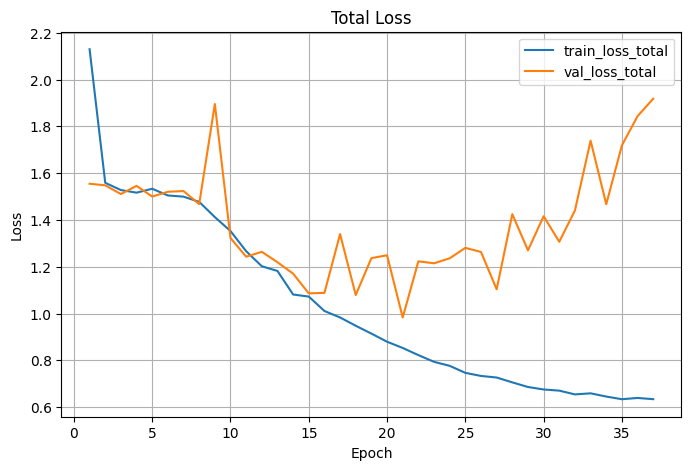

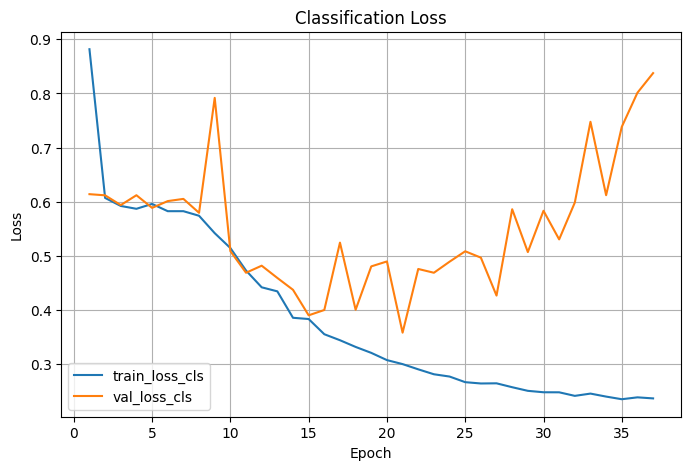

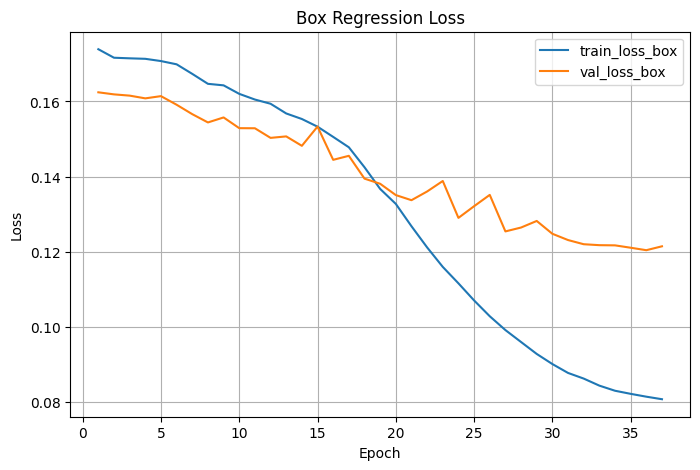

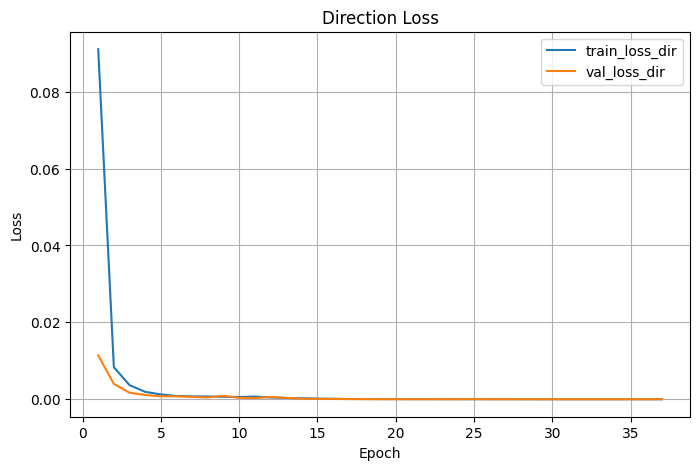

In [15]:
if not history:
    print("No history found.")
else:
    def get_series(key):
        return [h.get(key, None) for h in history]

    epochs = get_series("epoch")

    def plot_metric(title, train_key, val_key):
        train_vals = get_series(train_key)
        val_vals = get_series(val_key)

        # drop None safely (in case of missing keys)
        xs_t = [e for e, v in zip(epochs, train_vals) if v is not None]
        ys_t = [v for v in train_vals if v is not None]
        xs_v = [e for e, v in zip(epochs, val_vals) if v is not None]
        ys_v = [v for v in val_vals if v is not None]

        plt.figure(figsize=(8, 5))
        if ys_t:
            plt.plot(xs_t, ys_t, label=train_key)
        if ys_v:
            plt.plot(xs_v, ys_v, label=val_key)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.show()

    plot_metric("Total Loss", "train_loss_total", "val_loss_total")
    plot_metric("Classification Loss", "train_loss_cls", "val_loss_cls")
    plot_metric("Box Regression Loss", "train_loss_box", "val_loss_box")
    plot_metric("Direction Loss", "train_loss_dir", "val_loss_dir")

## 15. Inference kernel 

This section runs a single frame against the best checkpoint and visualizes both ground truth and prediction


RAW scores: max=0.8842 p99=0.1906 thr=0.55
Frame: 005488
GT boxes: 10
Pred after NMS: 6 | max kept score: 0.88422537


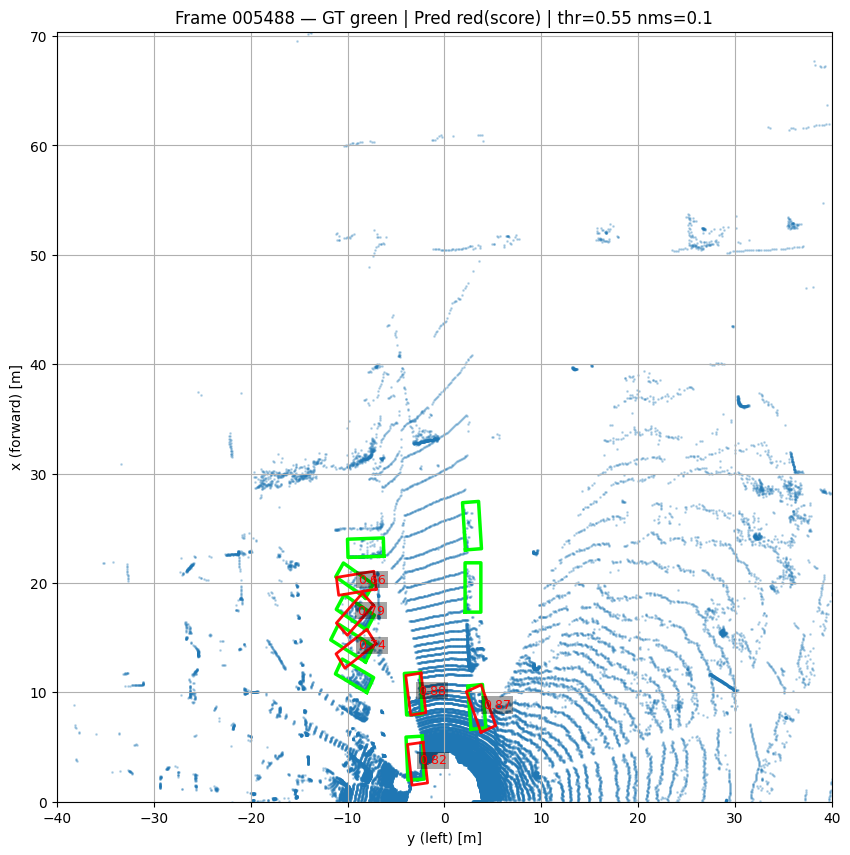

In [38]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

FRAME_ID = "005488"
CKPT_PATH = CHECKPOINT_DIR / "pointpillars_car_train_only_best.pth"

SCORE_THR = 0.55     
NMS_IOU_THR = 0.10     
MAX_DETS = 30
TOPK_BEFORE_NMS = 300   

def decode_from_anchors_and_deltas(anchors7: torch.Tensor, deltas7: torch.Tensor):
    xa, ya, za, la, wa, ha, ra = anchors7.unbind(-1)
    tx, ty, tz, tl, tw, th, tr = deltas7.unbind(-1)

    diag = torch.sqrt(la**2 + wa**2).clamp(min=1e-6)
    xg = xa + tx * diag
    yg = ya + ty * diag
    zg = za + tz * ha.clamp(min=1e-6)

    lg = la * torch.exp(tl)
    wg = wa * torch.exp(tw)
    hg = ha * torch.exp(th)

    yaw = ra + tr
    yaw = (yaw + math.pi) % (2.0 * math.pi) - math.pi

    return torch.stack([xg, yg, zg, lg, wg, hg, yaw], dim=-1)

def aabb_from_rotated(boxes7: np.ndarray):
    x = boxes7[:, 0]; y = boxes7[:, 1]
    l = boxes7[:, 3]; w = boxes7[:, 4]
    yaw = boxes7[:, 6]
    c = np.abs(np.cos(yaw)); s = np.abs(np.sin(yaw))
    half_x = 0.5 * (l * c + w * s)
    half_y = 0.5 * (l * s + w * c)
    x1 = x - half_x; x2 = x + half_x
    y1 = y - half_y; y2 = y + half_y
    return np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)

def nms_aabb_xy(boxes_xyxy: np.ndarray, scores: np.ndarray, iou_thr=0.2, max_dets=200):
    if boxes_xyxy.shape[0] == 0:
        return np.zeros((0,), dtype=np.int64)

    order = scores.argsort()[::-1]
    keep = []

    while order.size > 0 and len(keep) < max_dets:
        i = int(order[0])
        keep.append(i)
        if order.size == 1:
            break
        rest = order[1:]

        xx1 = np.maximum(boxes_xyxy[i, 0], boxes_xyxy[rest, 0])
        yy1 = np.maximum(boxes_xyxy[i, 1], boxes_xyxy[rest, 1])
        xx2 = np.minimum(boxes_xyxy[i, 2], boxes_xyxy[rest, 2])
        yy2 = np.minimum(boxes_xyxy[i, 3], boxes_xyxy[rest, 3])

        iw = np.maximum(0.0, xx2 - xx1)
        ih = np.maximum(0.0, yy2 - yy1)
        inter = iw * ih

        area_i = (boxes_xyxy[i, 2] - boxes_xyxy[i, 0]) * (boxes_xyxy[i, 3] - boxes_xyxy[i, 1])
        area_r = (boxes_xyxy[rest, 2] - boxes_xyxy[rest, 0]) * (boxes_xyxy[rest, 3] - boxes_xyxy[rest, 1])
        iou = inter / np.maximum(1e-6, area_i + area_r - inter)

        order = rest[iou < iou_thr]

    return np.asarray(keep, dtype=np.int64)

def box_corners_xy(box7: np.ndarray):
    x, y, _, l, w, _, yaw = map(float, box7)
    c = math.cos(yaw); s = math.sin(yaw)
    dx, dy = l / 2.0, w / 2.0
    local = np.array([[ dx,  dy], [-dx,  dy], [-dx, -dy], [ dx, -dy]], dtype=np.float32)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)
    pts = local @ R.T
    pts[:, 0] += x
    pts[:, 1] += y
    return pts

def draw_boxes_bev(ax, boxes7: np.ndarray, scores=None, color="r", lw=2, alpha=1.0,
                   show_score=True, score_fmt="{:.2f}", fontsize=9, text_offset=(0.2, 0.0)):
    if boxes7 is None or len(boxes7) == 0:
        return
    if scores is not None:
        scores = np.asarray(scores).reshape(-1)

    for i, b in enumerate(boxes7):
        c = box_corners_xy(b)
        poly = np.vstack([c, c[0]])
        ax.plot(poly[:, 1], poly[:, 0], color=color, lw=lw, alpha=alpha)

        if show_score and (scores is not None) and (i < scores.shape[0]):
            x, y = float(b[0]), float(b[1])
            dy, dx = float(text_offset[0]), float(text_offset[1])
            ax.text(
                y + dy, x + dx,  # plotting y vs x
                score_fmt.format(float(scores[i])),
                color=color,
                fontsize=fontsize,
                bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=1.5),
            )

bin_path = VEL_DIR / f"{FRAME_ID}.bin"
lab_path = LAB_DIR / f"{FRAME_ID}.txt"
cal_path = CAL_DIR / f"{FRAME_ID}.txt"

points_xyzi = load_kitti_velodyne(bin_path)

cars_cam = read_kitti_labels_car(lab_path)
R0_4, Tr_4 = read_calib(cal_path)
T_velo_to_rect = R0_4 @ Tr_4
T_rect_to_velo = inverse_rigid_transform(T_velo_to_rect)

gt_boxes_np = camera_cars_to_lidar_boxes(
    cars_cam=cars_cam,
    T_rect_to_velo=T_rect_to_velo,
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn as nn  

model = PointPillarsCarDetector().to(device).eval()

try:
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
    state = ckpt["model_state_dict"] if (isinstance(ckpt, dict) and "model_state_dict" in ckpt) else ckpt
except TypeError:
    ckpt = torch.load(CKPT_PATH, map_location=device)
    state = ckpt["model_state_dict"]

model.load_state_dict(state, strict=True)

pillar_points_np, pillar_indices_np, num_points_np, _ = pillarize(points_xyzi)

pillar_points = [torch.from_numpy(pillar_points_np).to(device).float()]
pillar_indices = [torch.from_numpy(pillar_indices_np).to(device).long()]
num_points = [torch.from_numpy(num_points_np).to(device).long()]

with torch.no_grad():
    preds = model(pillar_points, pillar_indices, num_points)

cls_logits = preds["cls_logits"][0]  # (A,H,W)
box_reg = preds["box_reg"][0]        # (A*7,H,W)
dir_logits = preds["dir_logits"][0]  # (A*2,H,W)

A = len(ANCHOR_YAWS)
Hh, Ww = cls_logits.shape[-2], cls_logits.shape[-1]

anchors = generate_anchors(device)   # (A,H,W,7)
assert anchors.shape[1] == Hh and anchors.shape[2] == Ww, f"anchors {anchors.shape} vs logits {(A,Hh,Ww)}"

box_reg = box_reg.reshape(A, 7, Hh, Ww).permute(0, 2, 3, 1).contiguous()       # (A,H,W,7)
dir_logits = dir_logits.reshape(A, 2, Hh, Ww).permute(0, 2, 3, 1).contiguous() # (A,H,W,2)

scores = torch.sigmoid(cls_logits)  # (A,H,W)
raw_max = float(scores.max().item())
raw_p99 = float(torch.quantile(scores.flatten(), 0.99).item())
print(f"RAW scores: max={raw_max:.4f} p99={raw_p99:.4f} thr={SCORE_THR}")

mask = scores >= SCORE_THR
idx = torch.nonzero(mask, as_tuple=False)  # (N,3)

if idx.numel() == 0:
    pred_boxes_nms = np.zeros((0, 7), dtype=np.float32)
    pred_scores_nms = np.zeros((0,), dtype=np.float32)
else:
    a_idx, x_idx, y_idx = idx[:, 0], idx[:, 1], idx[:, 2]

    anc_sel = anchors[a_idx, x_idx, y_idx]
    del_sel = box_reg[a_idx, x_idx, y_idx]
    boxes = decode_from_anchors_and_deltas(anc_sel, del_sel)

    # apply direction bin
    dir_cls = torch.argmax(dir_logits[a_idx, x_idx, y_idx], dim=-1)
    yaw = boxes[:, 6]
    yaw = torch.where(dir_cls > 0, yaw + math.pi, yaw)
    yaw = (yaw + math.pi) % (2.0 * math.pi) - math.pi
    boxes = boxes.clone()
    boxes[:, 6] = yaw

    scores_sel = scores[a_idx, x_idx, y_idx]

    boxes_np = boxes.detach().cpu().numpy().astype(np.float32)
    scores_np = scores_sel.detach().cpu().numpy().astype(np.float32)

    # TOP-K cap
    if scores_np.shape[0] > TOPK_BEFORE_NMS:
        topk_idx = np.argpartition(scores_np, -TOPK_BEFORE_NMS)[-TOPK_BEFORE_NMS:]
        boxes_np = boxes_np[topk_idx]
        scores_np = scores_np[topk_idx]

    # AABB NMS
    aabb = aabb_from_rotated(boxes_np)
    keep = nms_aabb_xy(aabb, scores_np, iou_thr=NMS_IOU_THR, max_dets=MAX_DETS)

    pred_boxes_nms = boxes_np[keep] if keep.size else boxes_np
    pred_scores_nms = scores_np[keep] if keep.size else scores_np

print("Frame:", FRAME_ID)
print("GT boxes:", gt_boxes_np.shape[0])
print("Pred after NMS:", pred_boxes_nms.shape[0], "| max kept score:", (pred_scores_nms.max() if pred_scores_nms.size else 0.0))

pts = points_xyzi.astype(np.float32)
roi = (pts[:, 0] >= X_MIN) & (pts[:, 0] < X_MAX) & (pts[:, 1] >= Y_MIN) & (pts[:, 1] < Y_MAX)
pts = pts[roi]

plt.figure(figsize=(10, 10))
ax = plt.gca()
ax.scatter(pts[:, 1], pts[:, 0], s=1, alpha=0.25)

# GT
if gt_boxes_np.shape[0] > 0:
    draw_boxes_bev(ax, gt_boxes_np, scores=None, color="lime", lw=2.5, alpha=1.0, show_score=False)

if pred_boxes_nms.shape[0] > 0:
    # sort preds by score descending for clearer labels
    order = np.argsort(pred_scores_nms)[::-1]
    pred_boxes_nms = pred_boxes_nms[order]
    pred_scores_nms = pred_scores_nms[order]
    draw_boxes_bev(ax, pred_boxes_nms, scores=pred_scores_nms, color="red", lw=2.0, alpha=0.95,
                   show_score=True, score_fmt="{:.2f}", fontsize=9, text_offset=(0.2, 0.0))

ax.set_xlim([Y_MIN, Y_MAX])
ax.set_ylim([X_MIN, X_MAX])
ax.set_xlabel("y (left) [m]")
ax.set_ylabel("x (forward) [m]")
ax.set_title(f"Frame {FRAME_ID} — GT green | Pred red(score) | thr={SCORE_THR} nms={NMS_IOU_THR}")
ax.grid(True)
plt.show()

## 15. Evaluation — Threshold Sweep Analysis

- Runs inference across multiple confidence thresholds, applying filtering, top-K selection, and NMS to refine detections.
- Matches predictions with ground truth using IoU-based greedy matching to compute TP, FP, and FN.
- Evaluates performance using Precision, Recall, F1, Accuracy, and AP, and visualizes trends across thresholds.



Frames available for eval: 101
Total GT cars in range: 384

=== Threshold sweep results (IoU match 0.10) ===
Frames: 101 | GT total: 384
thr   TP    FP    FN    Prec    Rec     F1      Acc     AP
0.05   253  1041   131  0.196  0.659  0.302  0.178  0.630
0.10   253  1055   131  0.193  0.659  0.299  0.176  0.630
0.15   253  1049   131  0.194  0.659  0.300  0.177  0.630
0.20   243    61   141  0.799  0.633  0.706  0.546  0.614
0.25   242    46   142  0.840  0.630  0.720  0.563  0.612
0.30   239    40   145  0.857  0.622  0.721  0.564  0.605
0.35   235    34   149  0.874  0.612  0.720  0.562  0.596
0.40   230    33   154  0.875  0.599  0.711  0.552  0.585
0.45   226    29   158  0.886  0.589  0.707  0.547  0.575
0.50   223    28   161  0.888  0.581  0.702  0.541  0.568


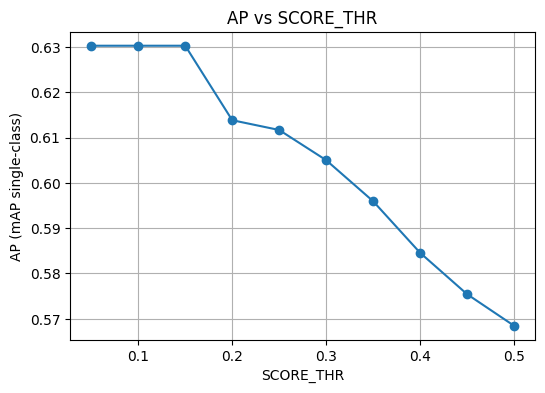

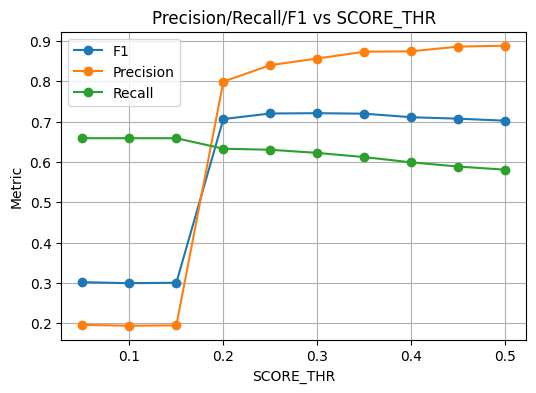

In [39]:
START_ID = 3000
END_ID   = 3100  

SCORE_THR_LIST = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

NMS_IOU_THR = 0.10
MAX_DETS = 30
TOPK_BEFORE_NMS = 300

IOU_MATCH_THR = 0.10
CKPT_PATH = CHECKPOINT_DIR / "pointpillars_car_train_only_best.pth"


def decode_from_anchors_and_deltas(anchors7: torch.Tensor, deltas7: torch.Tensor):
    xa, ya, za, la, wa, ha, ra = anchors7.unbind(-1)
    tx, ty, tz, tl, tw, th, tr = deltas7.unbind(-1)
    diag = torch.sqrt(la**2 + wa**2).clamp(min=1e-6)

    xg = xa + tx * diag
    yg = ya + ty * diag
    zg = za + tz * ha.clamp(min=1e-6)

    lg = la * torch.exp(tl)
    wg = wa * torch.exp(tw)
    hg = ha * torch.exp(th)

    yaw = ra + tr
    yaw = (yaw + math.pi) % (2.0 * math.pi) - math.pi

    return torch.stack([xg, yg, zg, lg, wg, hg, yaw], dim=-1)

def aabb_from_rotated(boxes7: np.ndarray):
    x = boxes7[:, 0]; y = boxes7[:, 1]
    l = boxes7[:, 3]; w = boxes7[:, 4]
    yaw = boxes7[:, 6]
    c = np.abs(np.cos(yaw)); s = np.abs(np.sin(yaw))
    half_x = 0.5 * (l * c + w * s)
    half_y = 0.5 * (l * s + w * c)
    x1 = x - half_x; x2 = x + half_x
    y1 = y - half_y; y2 = y + half_y
    return np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)

def nms_aabb_xy(boxes_xyxy: np.ndarray, scores: np.ndarray, iou_thr=0.2, max_dets=200):
    if boxes_xyxy.shape[0] == 0:
        return np.zeros((0,), dtype=np.int64)

    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0 and len(keep) < max_dets:
        i = int(order[0])
        keep.append(i)
        if order.size == 1:
            break
        rest = order[1:]

        xx1 = np.maximum(boxes_xyxy[i, 0], boxes_xyxy[rest, 0])
        yy1 = np.maximum(boxes_xyxy[i, 1], boxes_xyxy[rest, 1])
        xx2 = np.minimum(boxes_xyxy[i, 2], boxes_xyxy[rest, 2])
        yy2 = np.minimum(boxes_xyxy[i, 3], boxes_xyxy[rest, 3])

        iw = np.maximum(0.0, xx2 - xx1)
        ih = np.maximum(0.0, yy2 - yy1)
        inter = iw * ih

        area_i = (boxes_xyxy[i, 2] - boxes_xyxy[i, 0]) * (boxes_xyxy[i, 3] - boxes_xyxy[i, 1])
        area_r = (boxes_xyxy[rest, 2] - boxes_xyxy[rest, 0]) * (boxes_xyxy[rest, 3] - boxes_xyxy[rest, 1])
        iou = inter / np.maximum(1e-6, area_i + area_r - inter)

        order = rest[iou < iou_thr]

    return np.asarray(keep, dtype=np.int64)

def iou_aabb_matrix(a: np.ndarray, b: np.ndarray):
    if a.shape[0] == 0 or b.shape[0] == 0:
        return np.zeros((a.shape[0], b.shape[0]), dtype=np.float32)

    xx1 = np.maximum(a[:, None, 0], b[None, :, 0])
    yy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    xx2 = np.minimum(a[:, None, 2], b[None, :, 2])
    yy2 = np.minimum(a[:, None, 3], b[None, :, 3])

    iw = np.maximum(0.0, xx2 - xx1)
    ih = np.maximum(0.0, yy2 - yy1)
    inter = iw * ih

    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / np.maximum(1e-6, union)

def match_dets_to_gt(pred_boxes7, pred_scores, gt_boxes7, iou_thr=0.5):
    """
    Returns tp, fp arrays in *score-desc order*, and fn count.
    """
    Np = pred_boxes7.shape[0]
    Ng = gt_boxes7.shape[0]
    tp = np.zeros((Np,), dtype=np.int32)
    fp = np.zeros((Np,), dtype=np.int32)

    if Ng == 0:
        fp[:] = 1
        return tp, fp, 0, np.sort(pred_scores)[::-1] if pred_scores.size else np.zeros((0,), np.float32)

    if Np == 0:
        return tp, fp, Ng, np.zeros((0,), np.float32)

    order = np.argsort(pred_scores)[::-1]
    pred_boxes7 = pred_boxes7[order]
    pred_scores = pred_scores[order]

    pa = aabb_from_rotated(pred_boxes7)
    ga = aabb_from_rotated(gt_boxes7)

    ious = iou_aabb_matrix(pa, ga)
    gt_used = np.zeros((Ng,), dtype=np.bool_)

    for i in range(Np):
        j = int(np.argmax(ious[i]))
        best = float(ious[i, j])
        if best >= iou_thr and (not gt_used[j]):
            tp[i] = 1
            gt_used[j] = True
        else:
            fp[i] = 1

    fn = int((~gt_used).sum())
    return tp, fp, fn, pred_scores  # scores already sorted desc

def ap_from_tp_fp(tp_sorted, fp_sorted, n_gt):
    if n_gt == 0:
        return 0.0, np.array([0.0]), np.array([0.0])

    tp_cum = np.cumsum(tp_sorted)
    fp_cum = np.cumsum(fp_sorted)

    rec = tp_cum / max(1, n_gt)
    prec = tp_cum / np.maximum(1, tp_cum + fp_cum)

    mrec = np.concatenate([[0.0], rec, [1.0]])
    mpre = np.concatenate([[0.0], prec, [0.0]])
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))
    return ap, rec, prec

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn as nn  # ensure nn alias

model = PointPillarsCarDetector().to(device).eval()

try:
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=True)
    state = ckpt["model_state_dict"] if (isinstance(ckpt, dict) and "model_state_dict" in ckpt) else ckpt
except TypeError:
    ckpt = torch.load(CKPT_PATH, map_location=device)
    state = ckpt["model_state_dict"]

model.load_state_dict(state, strict=True)

anchors = generate_anchors(device)  # (A,H,W,7)
A = anchors.shape[0]
Hh, Ww = anchors.shape[1], anchors.shape[2]


frame_ids = [f"{i:06d}" for i in range(START_ID, END_ID + 1)]
valid_frames = []
gt_cache = {}
pc_cache = {}
cal_cache = {}

# Cache GT + points once to make sweep faster
for fid in frame_ids:
    bin_path = VEL_DIR / f"{fid}.bin"
    lab_path = LAB_DIR / f"{fid}.txt"
    cal_path = CAL_DIR / f"{fid}.txt"
    if (not bin_path.exists()) or (not lab_path.exists()) or (not cal_path.exists()):
        continue

    points_xyzi = load_kitti_velodyne(bin_path)
    cars_cam = read_kitti_labels_car(lab_path)
    R0_4, Tr_4 = read_calib(cal_path)
    T_rect_to_velo = inverse_rigid_transform(R0_4 @ Tr_4)

    gt_boxes_np = camera_cars_to_lidar_boxes(
        cars_cam=cars_cam,
        T_rect_to_velo=T_rect_to_velo,
        x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX
    ).astype(np.float32)

    valid_frames.append(fid)
    pc_cache[fid] = points_xyzi
    gt_cache[fid] = gt_boxes_np

print("Frames available for eval:", len(valid_frames))
total_gt_all = int(sum(gt_cache[f].shape[0] for f in valid_frames))
print("Total GT cars in range:", total_gt_all)


@torch.no_grad()
def infer_one(points_xyzi: np.ndarray, score_thr: float):
    pillar_points_np, pillar_indices_np, num_points_np, _ = pillarize(points_xyzi)
    pillar_points = [torch.from_numpy(pillar_points_np).to(device).float()]
    pillar_indices = [torch.from_numpy(pillar_indices_np).to(device).long()]
    num_points = [torch.from_numpy(num_points_np).to(device).long()]

    preds = model(pillar_points, pillar_indices, num_points)

    cls_logits = preds["cls_logits"][0]
    box_reg = preds["box_reg"][0]
    dir_logits = preds["dir_logits"][0]

    H, W = cls_logits.shape[-2], cls_logits.shape[-1]
    if (H != Hh) or (W != Ww):
        raise RuntimeError(f"Head H/W mismatch: logits {(H,W)} vs anchors {(Hh,Ww)}")

    box_reg = box_reg.reshape(A, 7, H, W).permute(0, 2, 3, 1).contiguous()
    dir_logits = dir_logits.reshape(A, 2, H, W).permute(0, 2, 3, 1).contiguous()

    scores = torch.sigmoid(cls_logits)
    idx = torch.nonzero(scores >= score_thr, as_tuple=False)

    if idx.numel() == 0:
        return np.zeros((0, 7), np.float32), np.zeros((0,), np.float32)

    a_idx, x_idx, y_idx = idx[:, 0], idx[:, 1], idx[:, 2]
    anc_sel = anchors[a_idx, x_idx, y_idx]
    del_sel = box_reg[a_idx, x_idx, y_idx]

    boxes = decode_from_anchors_and_deltas(anc_sel, del_sel)

    dir_cls = torch.argmax(dir_logits[a_idx, x_idx, y_idx], dim=-1)
    yaw = boxes[:, 6]
    yaw = torch.where(dir_cls > 0, yaw + math.pi, yaw)
    yaw = (yaw + math.pi) % (2.0 * math.pi) - math.pi
    boxes = boxes.clone()
    boxes[:, 6] = yaw

    scores_sel = scores[a_idx, x_idx, y_idx]

    boxes_np = boxes.detach().cpu().numpy().astype(np.float32)
    scores_np = scores_sel.detach().cpu().numpy().astype(np.float32)

    if scores_np.shape[0] > TOPK_BEFORE_NMS:
        topk_idx = np.argpartition(scores_np, -TOPK_BEFORE_NMS)[-TOPK_BEFORE_NMS:]
        boxes_np = boxes_np[topk_idx]
        scores_np = scores_np[topk_idx]

    aabb = aabb_from_rotated(boxes_np)
    keep = nms_aabb_xy(aabb, scores_np, iou_thr=NMS_IOU_THR, max_dets=MAX_DETS)

    if keep.size:
        boxes_np = boxes_np[keep]
        scores_np = scores_np[keep]

    return boxes_np, scores_np

results = []

for thr in SCORE_THR_LIST:
    TP_total = 0
    FP_total = 0
    FN_total = 0

    all_tp = []
    all_fp = []
    all_scores = []

    total_gt = 0

    for fid in valid_frames:
        points_xyzi = pc_cache[fid]
        gt_boxes = gt_cache[fid]
        total_gt += int(gt_boxes.shape[0])

        pred_boxes, pred_scores = infer_one(points_xyzi, thr)

        tp_sorted, fp_sorted, fn, scores_sorted = match_dets_to_gt(
            pred_boxes, pred_scores, gt_boxes, iou_thr=IOU_MATCH_THR
        )

        TP_total += int(tp_sorted.sum())
        FP_total += int(fp_sorted.sum())
        FN_total += int(fn)

        all_tp.append(tp_sorted)
        all_fp.append(fp_sorted)
        all_scores.append(scores_sorted)

    if total_gt == 0:
        AP = 0.0
    else:
        tp_all = np.concatenate(all_tp) if len(all_tp) else np.zeros((0,), np.int32)
        fp_all = np.concatenate(all_fp) if len(all_fp) else np.zeros((0,), np.int32)
        scores_all = np.concatenate(all_scores) if len(all_scores) else np.zeros((0,), np.float32)

        if scores_all.size == 0:
            AP = 0.0
        else:
            glob_order = np.argsort(scores_all)[::-1]
            AP, _, _ = ap_from_tp_fp(tp_all[glob_order], fp_all[glob_order], total_gt)

    precision = TP_total / max(1, (TP_total + FP_total))
    recall = TP_total / max(1, (TP_total + FN_total))
    f1 = 2 * precision * recall / max(1e-12, (precision + recall))
    acc_det = TP_total / max(1, (TP_total + FP_total + FN_total))

    results.append({
        "thr": thr,
        "TP": TP_total,
        "FP": FP_total,
        "FN": FN_total,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "acc_det": acc_det,
        "AP": AP,
    })


print("\n=== Threshold sweep results (IoU match %.2f) ===" % IOU_MATCH_THR)
print("Frames:", len(valid_frames), "| GT total:", total_gt_all)
print("thr   TP    FP    FN    Prec    Rec     F1      Acc     AP")
for r in results:
    print(f"{r['thr']:.2f}  {r['TP']:4d}  {r['FP']:4d}  {r['FN']:4d}  "
          f"{r['precision']:.3f}  {r['recall']:.3f}  {r['f1']:.3f}  {r['acc_det']:.3f}  {r['AP']:.3f}")


ths = [r["thr"] for r in results]
aps = [r["AP"] for r in results]
f1s = [r["f1"] for r in results]
precs = [r["precision"] for r in results]
recs = [r["recall"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(ths, aps, marker="o")
plt.xlabel("SCORE_THR")
plt.ylabel("AP (mAP single-class)")
plt.title("AP vs SCORE_THR")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(ths, f1s, marker="o", label="F1")
plt.plot(ths, precs, marker="o", label="Precision")
plt.plot(ths, recs, marker="o", label="Recall")
plt.xlabel("SCORE_THR")
plt.ylabel("Metric")
plt.title("Precision/Recall/F1 vs SCORE_THR")
plt.legend()
plt.grid(True)
plt.show()